# Model Performance — Reproducing LIDC-IDRI Classification (Baseline Pipeline)

_Author&nbsp;• Saam Nazempour  |  MPhil Data Intensive Science, University of Cambridge_

This notebook reproduces the baseline classification pipeline from **Escudero Sánchez et al. (2022)** using 3D radiomic features extracted from the LIDC-IDRI dataset.

### Steps:

1. **Preliminary: IQR Analysis**  
   Visual inspection of feature distributions and separation across tumour classes.

2. **Feature Selection**  
   Kruskal-Wallis test with FDR correction followed by correlation filtering  
   → Final set of 34 features

3. **Model Training**  
   Train and evaluate Random Forest, XGBoost, and SVM using 5-fold cross-validation on the imbalanced dataset

4. **Model Interpretation**  
   SHAP analysis to interpret feature importance and generate summary plots

5. **Supplementary Plots**  

> **Goal:** Reproduce the original model performance and interpretation using the baseline feature set.



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import shap

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pingouin as pg

src_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(src_path)

from plotting import (
    plot_iqr_by_wavelength,
    plot_shap_summary_and_bar,
    plot_rm_corr_heatmaps,
    plot_kw_pvalues
)

from feature_selection import (
    kruskal_fdr_corr_filter
)

from ML import (
    compute_featurewise_model_scores
)

In [ ]:
df_combined_uncorr = pd.read_csv('../data/Photoacoustic_Study/csv/All_features_uncorrected_all_tumours_with_metadata.csv')
df_combined_uncorr["Model"] = df_combined_uncorr["Model"].str.lower()

### 1. Preliminary IQR Study

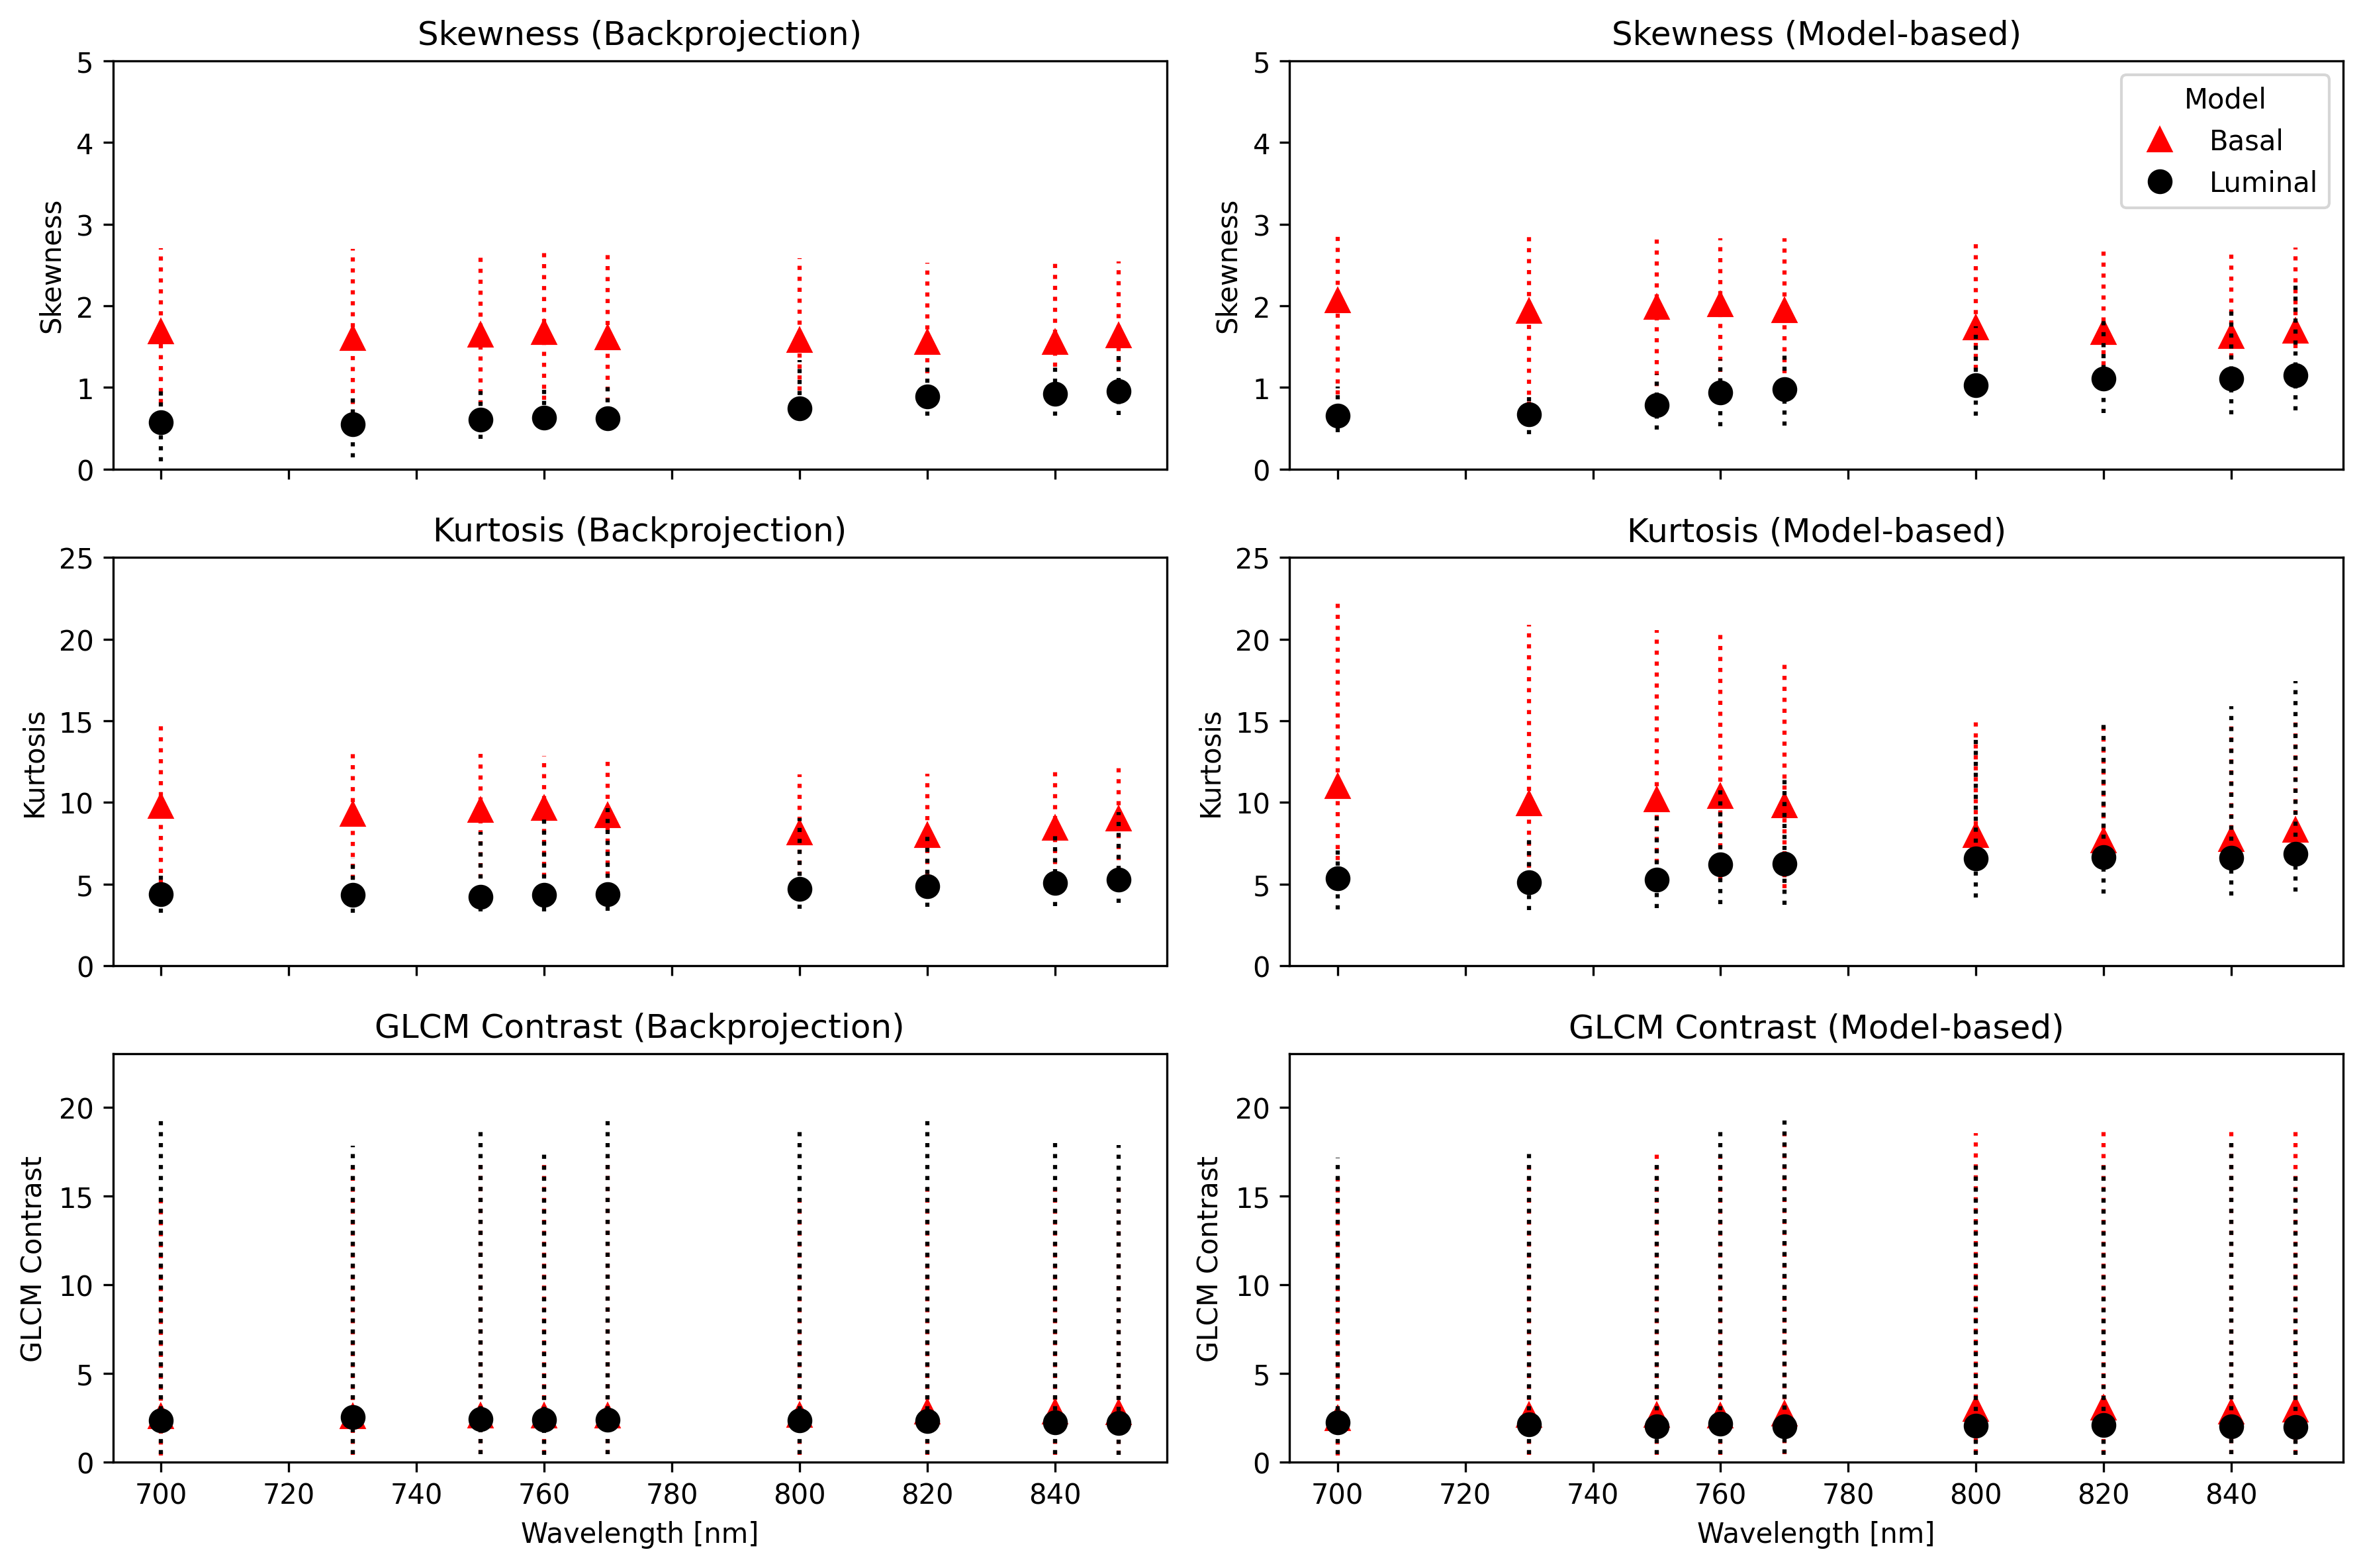

In [5]:
plot_iqr_by_wavelength(
    df=df_combined_uncorr,
    features=["original_firstorder_Skewness", "original_firstorder_Kurtosis", "original_glcm_Contrast"],
    titles=["Skewness", "Kurtosis", "GLCM Contrast"],
    y_lims=[(0, 5), (0, 25), (0, 23)],
    recons=["BP", "MB"],
    save_path="../plots/Distributions_plots/IQR_plots_uncorrected.png"
)

### 2. Feature Selection

In [ ]:
df_combined = pd.read_csv('../data/Photoacoustic_Study/csv/All_features_all_tumours_with_metadata.csv')

In [7]:
final_features, kw_df = kruskal_fdr_corr_filter(df_combined, target_col="Model", subject_col="PatientName")

df_final = df_combined[["PatientName", "Model"] + final_features].copy()

✅ 69 features selected after BH correction (FDR < 0.25)
✅ 34 features retained after correlation filtering


In [7]:
final_features

['GLCM Imc2',
 'FO 10Percentile',
 'GLRLM LongRunHighGrayLevelEmphasis',
 'GLRLM GrayLevelNonUniformity',
 'GLRLM GrayLevelNonUniformityNormalized',
 'GLRLM RunEntropy',
 'GLSZM SmallAreaEmphasis',
 'FO Variance',
 'GLSZM LowGrayLevelZoneEmphasis',
 'GLSZM GrayLevelNonUniformity',
 'GLCM Contrast',
 'GLCM ClusterTendency',
 'FO Skewness',
 'GLSZM GrayLevelNonUniformityNormalized',
 'GLDM DependenceNonUniformityNormalized',
 'GLCM Idn',
 'GLRLM LongRunLowGrayLevelEmphasis',
 'GLCM MCC',
 'GLCM ClusterProminence',
 'NGTDM Coarseness',
 'NGTDM Strength',
 'GLRLM GrayLevelVariance',
 'GLCM ClusterShade',
 'FO Minimum',
 'NGTDM Busyness',
 'GLDM SmallDependenceLowGrayLevelEmphasis',
 'GLCM MaximumProbability',
 'GLCM Idmn',
 'GLRLM RunLengthNonUniformity',
 'FO Kurtosis',
 'GLSZM ZoneVariance',
 'GLCM Imc1',
 'GLDM GrayLevelVariance',
 'FO 90Percentile']

### 3. Model Training and Evaluation

In [8]:
# Inputs
X = df_combined[final_features]
y = df_combined["Model"]

# Use stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Classifier setup
models = {
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3,
        learning_rate=1.0
    ),
    "SVM (RBF kernel)": make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf",
            C=1.0,
            gamma=0.05,
            tol=1e-3,
            probability=True,
            random_state=42
        )
    )
}

# Run CV
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"✅ {name}: {scores.mean():.3f} ± {scores.std():.3f}")

✅ Random Forest: 0.963 ± 0.013
✅ Gradient Boosting: 1.000 ± 0.000
✅ SVM (RBF kernel): 0.987 ± 0.006


### 4. Model Interpretation (SHAP)

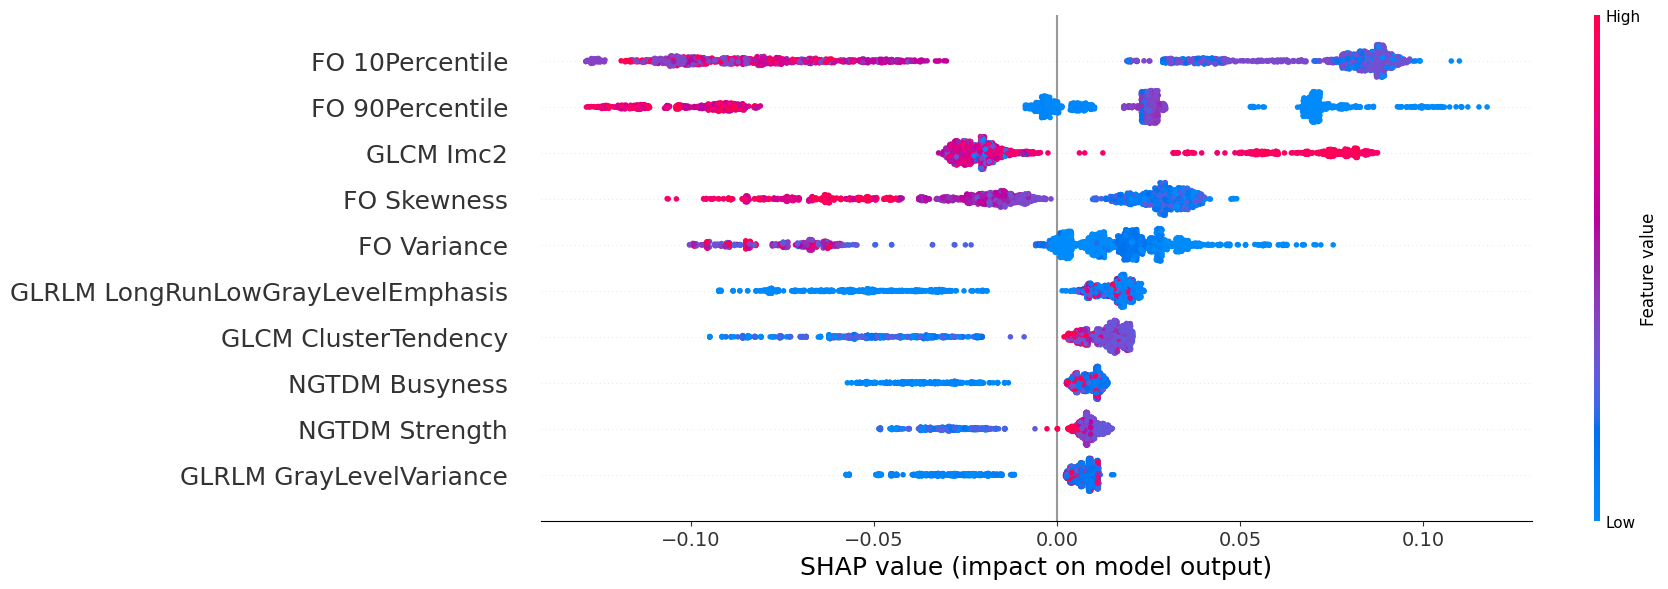

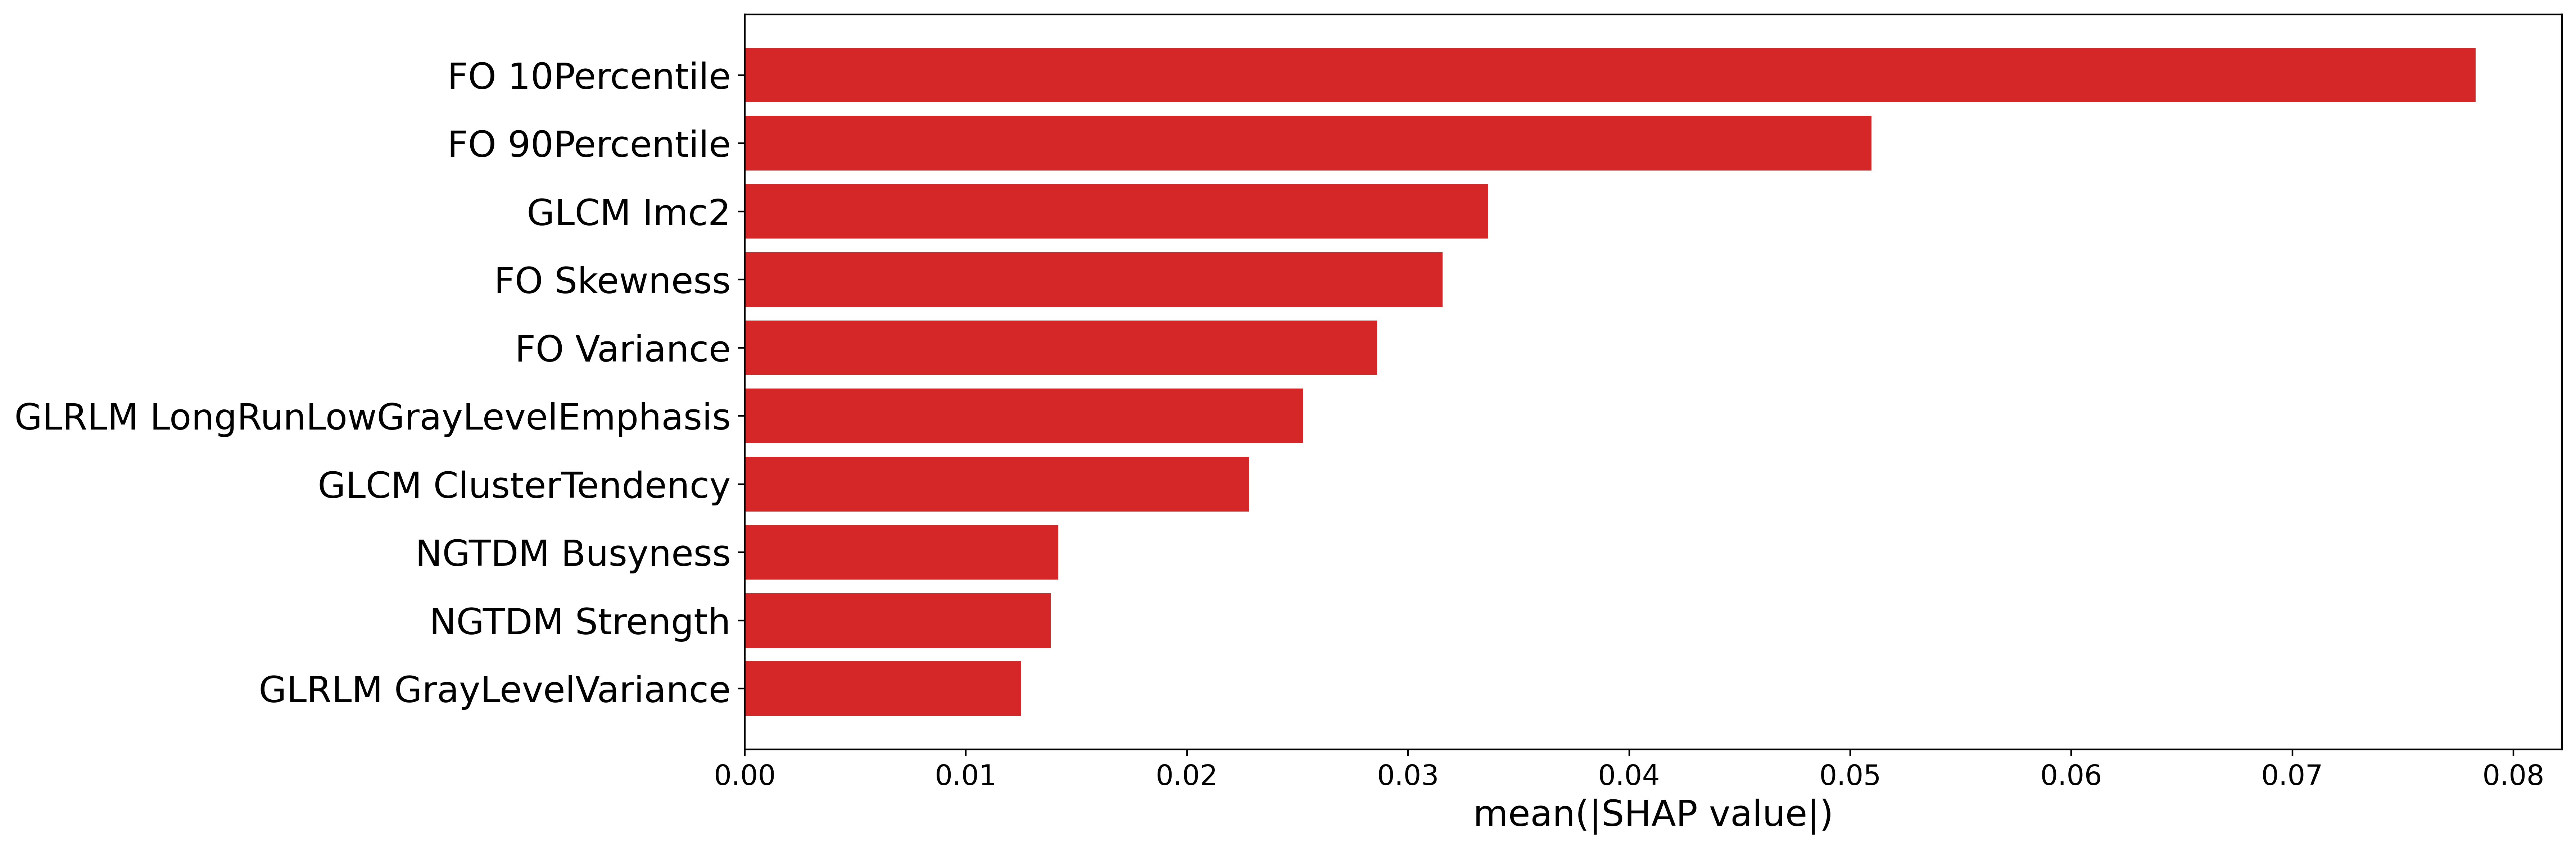

In [9]:
# Fit model
le = LabelEncoder()
y_encoded = le.fit_transform(y)
rf = RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3
    )
rf.fit(X, y_encoded)

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_values_class1 = shap_values[:, :, 1]

plot_shap_summary_and_bar(shap_values_class1, X, save_prefix="shap_full")

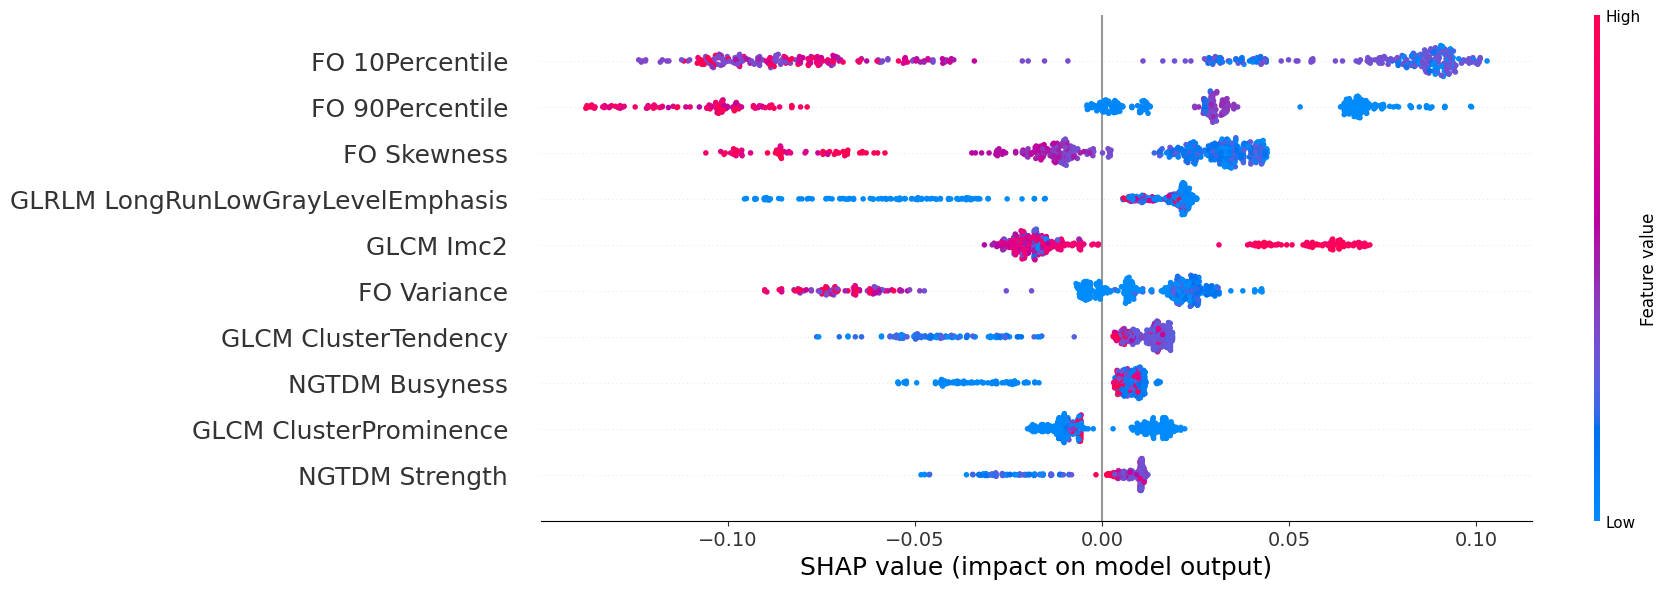

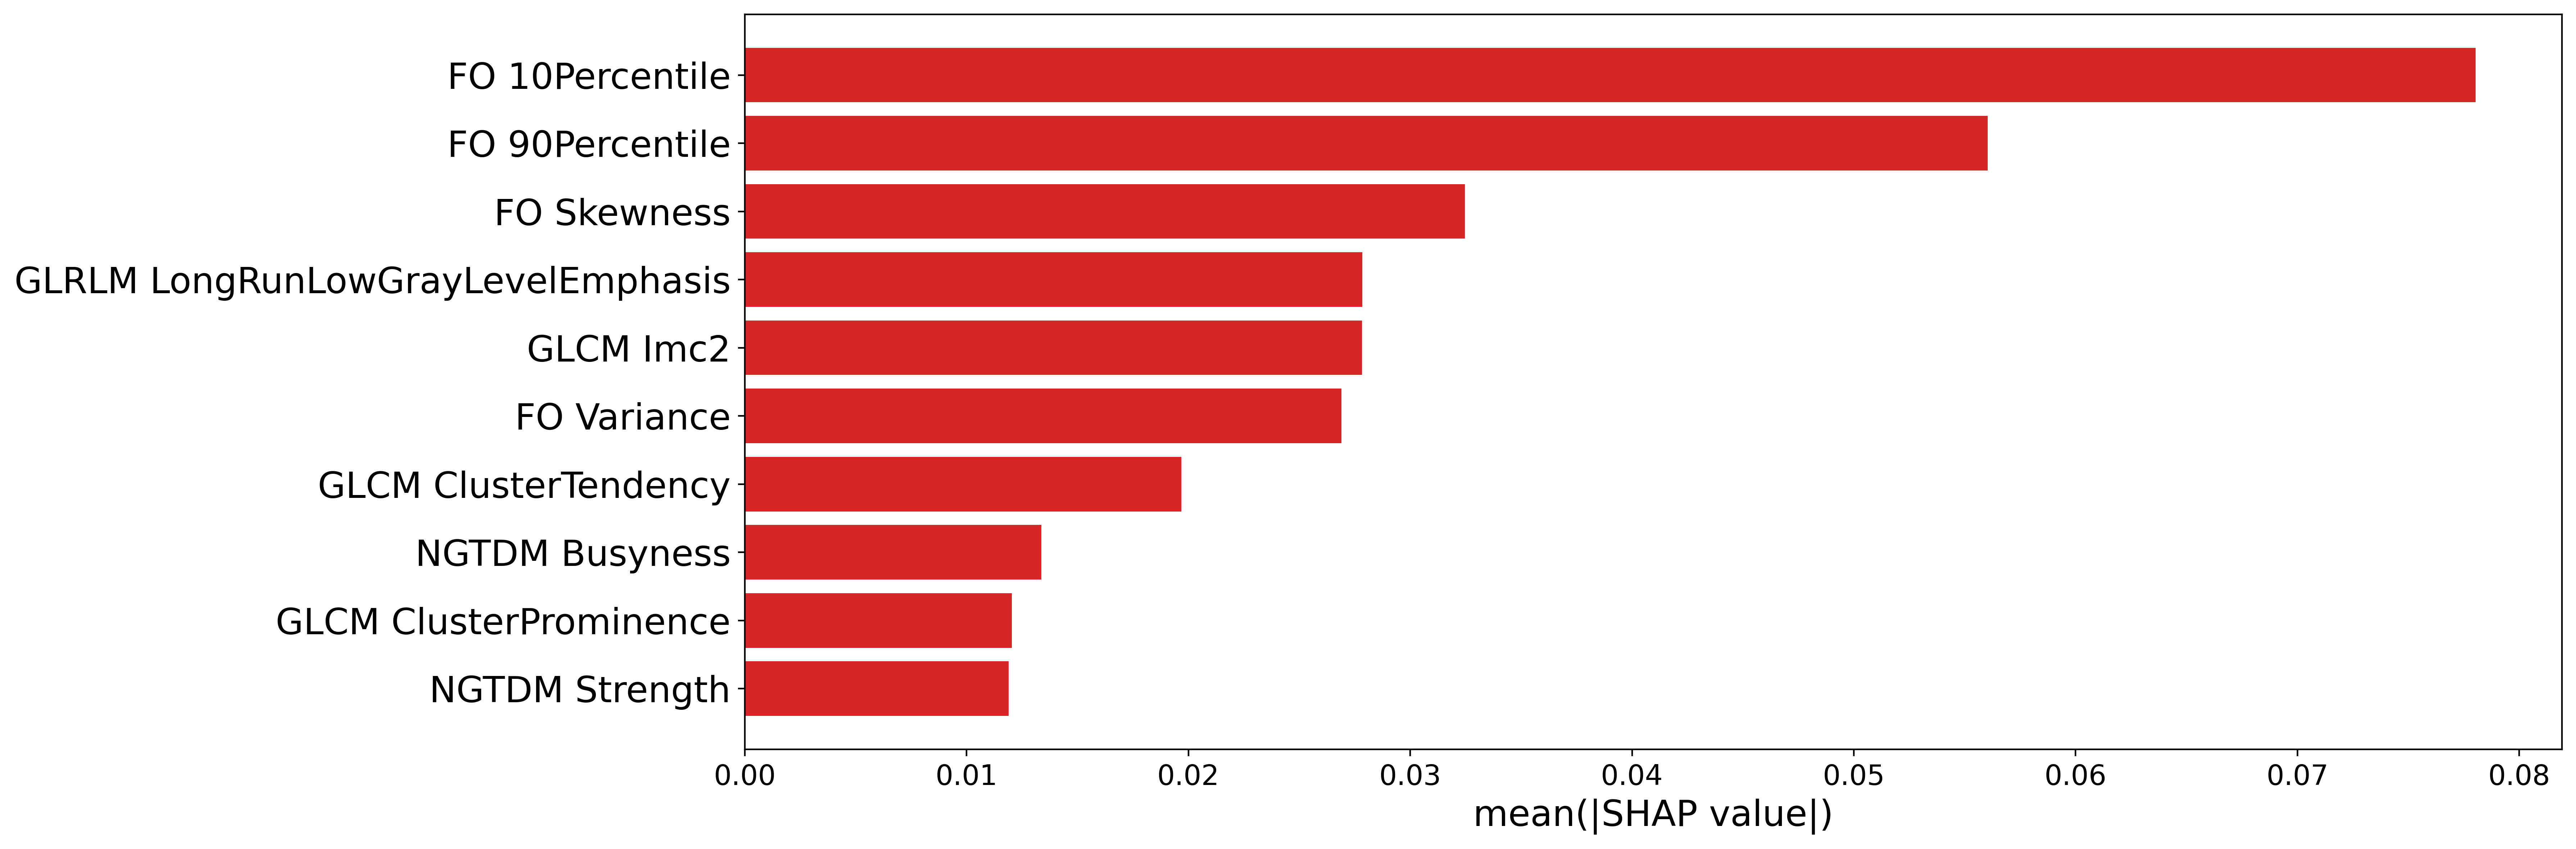

In [10]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Create CV split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(cv.split(X, y_encoded))  # just the first fold

# Split data
X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

# Train model
rf = RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=3
    )
rf.fit(X_train, y_train)

# Compute SHAP on validation fold
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_val)
shap_values_class1 = shap_values[:, :, 1]

plot_shap_summary_and_bar(shap_values_class1, X_val, save_prefix="shap_onefold")


### 5. Supplementary Plots

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covarianc

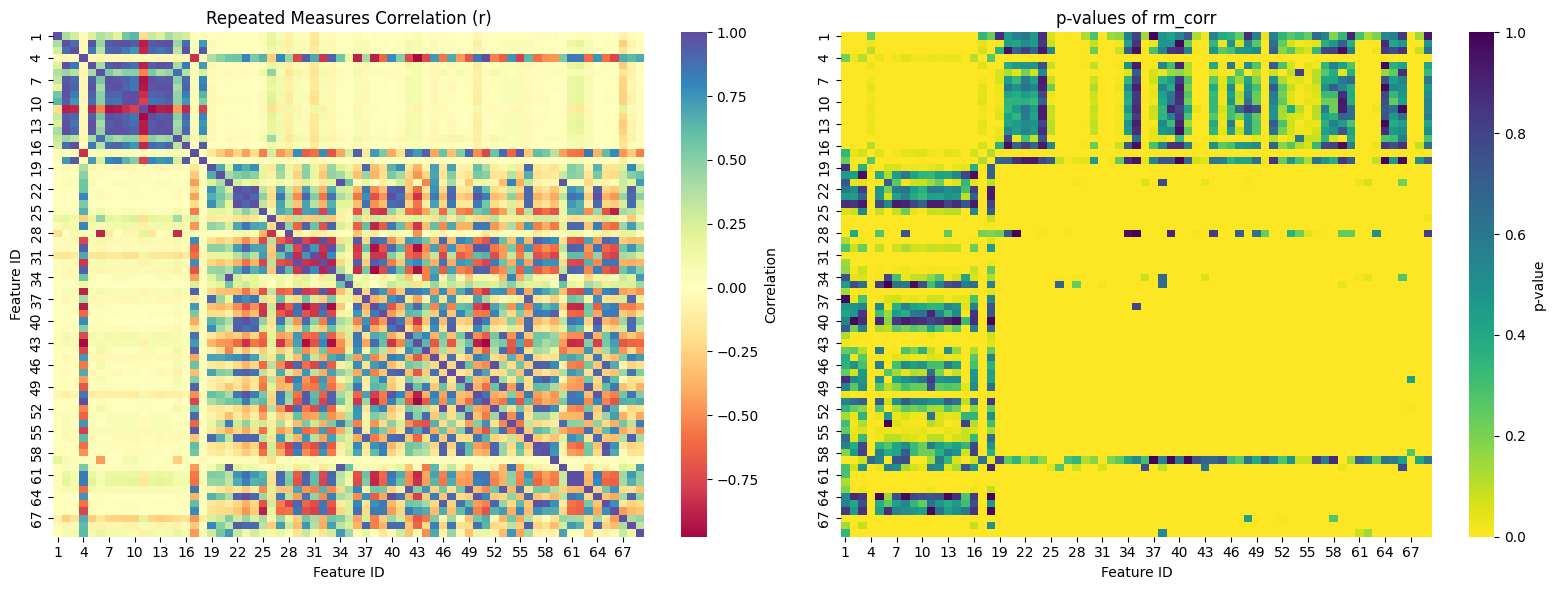

In [21]:
selected_features_kw = kw_df[kw_df["Keep"]].index.tolist()
df_selected = df_combined[selected_features_kw + ['PatientName']]
plot_rm_corr_heatmaps(df_selected, selected_features_kw)


In [23]:
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns
df_scores = compute_featurewise_model_scores(df_combined, feature_cols)
display(df_scores)

,ID,Feature,Random Forest,Gradient Boosting,SVM,Average
0,3,FO Energy,1.000000,0.997357,0.864635,0.953997
1,16,FO TotalEnergy,1.000000,0.997357,0.864635,0.953997
2,2,FO 90Percentile,1.000000,1.000000,0.782180,0.927393
3,14,FO RootMeanSquared,1.000000,1.000000,0.769837,0.923279
4,9,FO Mean,1.000000,0.998675,0.739858,0.912844
...,...,...,...,...,...,...
88,30,GLCM Idmn,0.523827,0.552932,0.551590,0.542783
89,37,GLCM JointEntropy,0.528665,0.575840,0.522936,0.542480
90,62,GLRLM LongRunHighGrayLevelEmphasis,0.514569,0.550728,0.547623,0.537640
91,92,NGTDM Contrast,0.534393,0.548063,0.527780,0.536745


In [ ]:
# Step 1: Extract discarded features (those not passing BH correction at FDR < 0.25)
discarded_df = kw_df[~kw_df["Keep"]].copy()

# Step 2: Add ranks (based on original p-value, ascending)
discarded_df["rank"] = discarded_df["p_value"].rank(method="first").astype(int)

# Step 3: Sort by p-value
discarded_df_sorted = discarded_df.sort_values("p_value")[["p_value", "rank", "p_adj"]]
discarded_df_sorted = discarded_df_sorted.rename(columns={"p_adj": "corrected value"})
discarded_df_sorted.index.name = "Feature Name"

# Optional: display full table
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(discarded_df_sorted)


,p_value,rank,corrected value
Feature Name,,,
GLCM DifferenceEntropy,0.210026,1,0.279035
GLDM LargeDependenceHighGrayLevelEmphasis,0.218651,2,0.286402
GLCM SumAverage,0.245756,4,0.313086
GLCM JointAverage,0.245756,3,0.313086
GLCM Autocorrelation,0.320261,5,0.402490
NGTDM Complexity,0.334047,6,0.414219
GLRLM HighGrayLevelRunEmphasis,0.383103,7,0.468797
GLCM Correlation,0.423582,8,0.509530
GLDM DependenceVariance,0.427348,9,0.509530


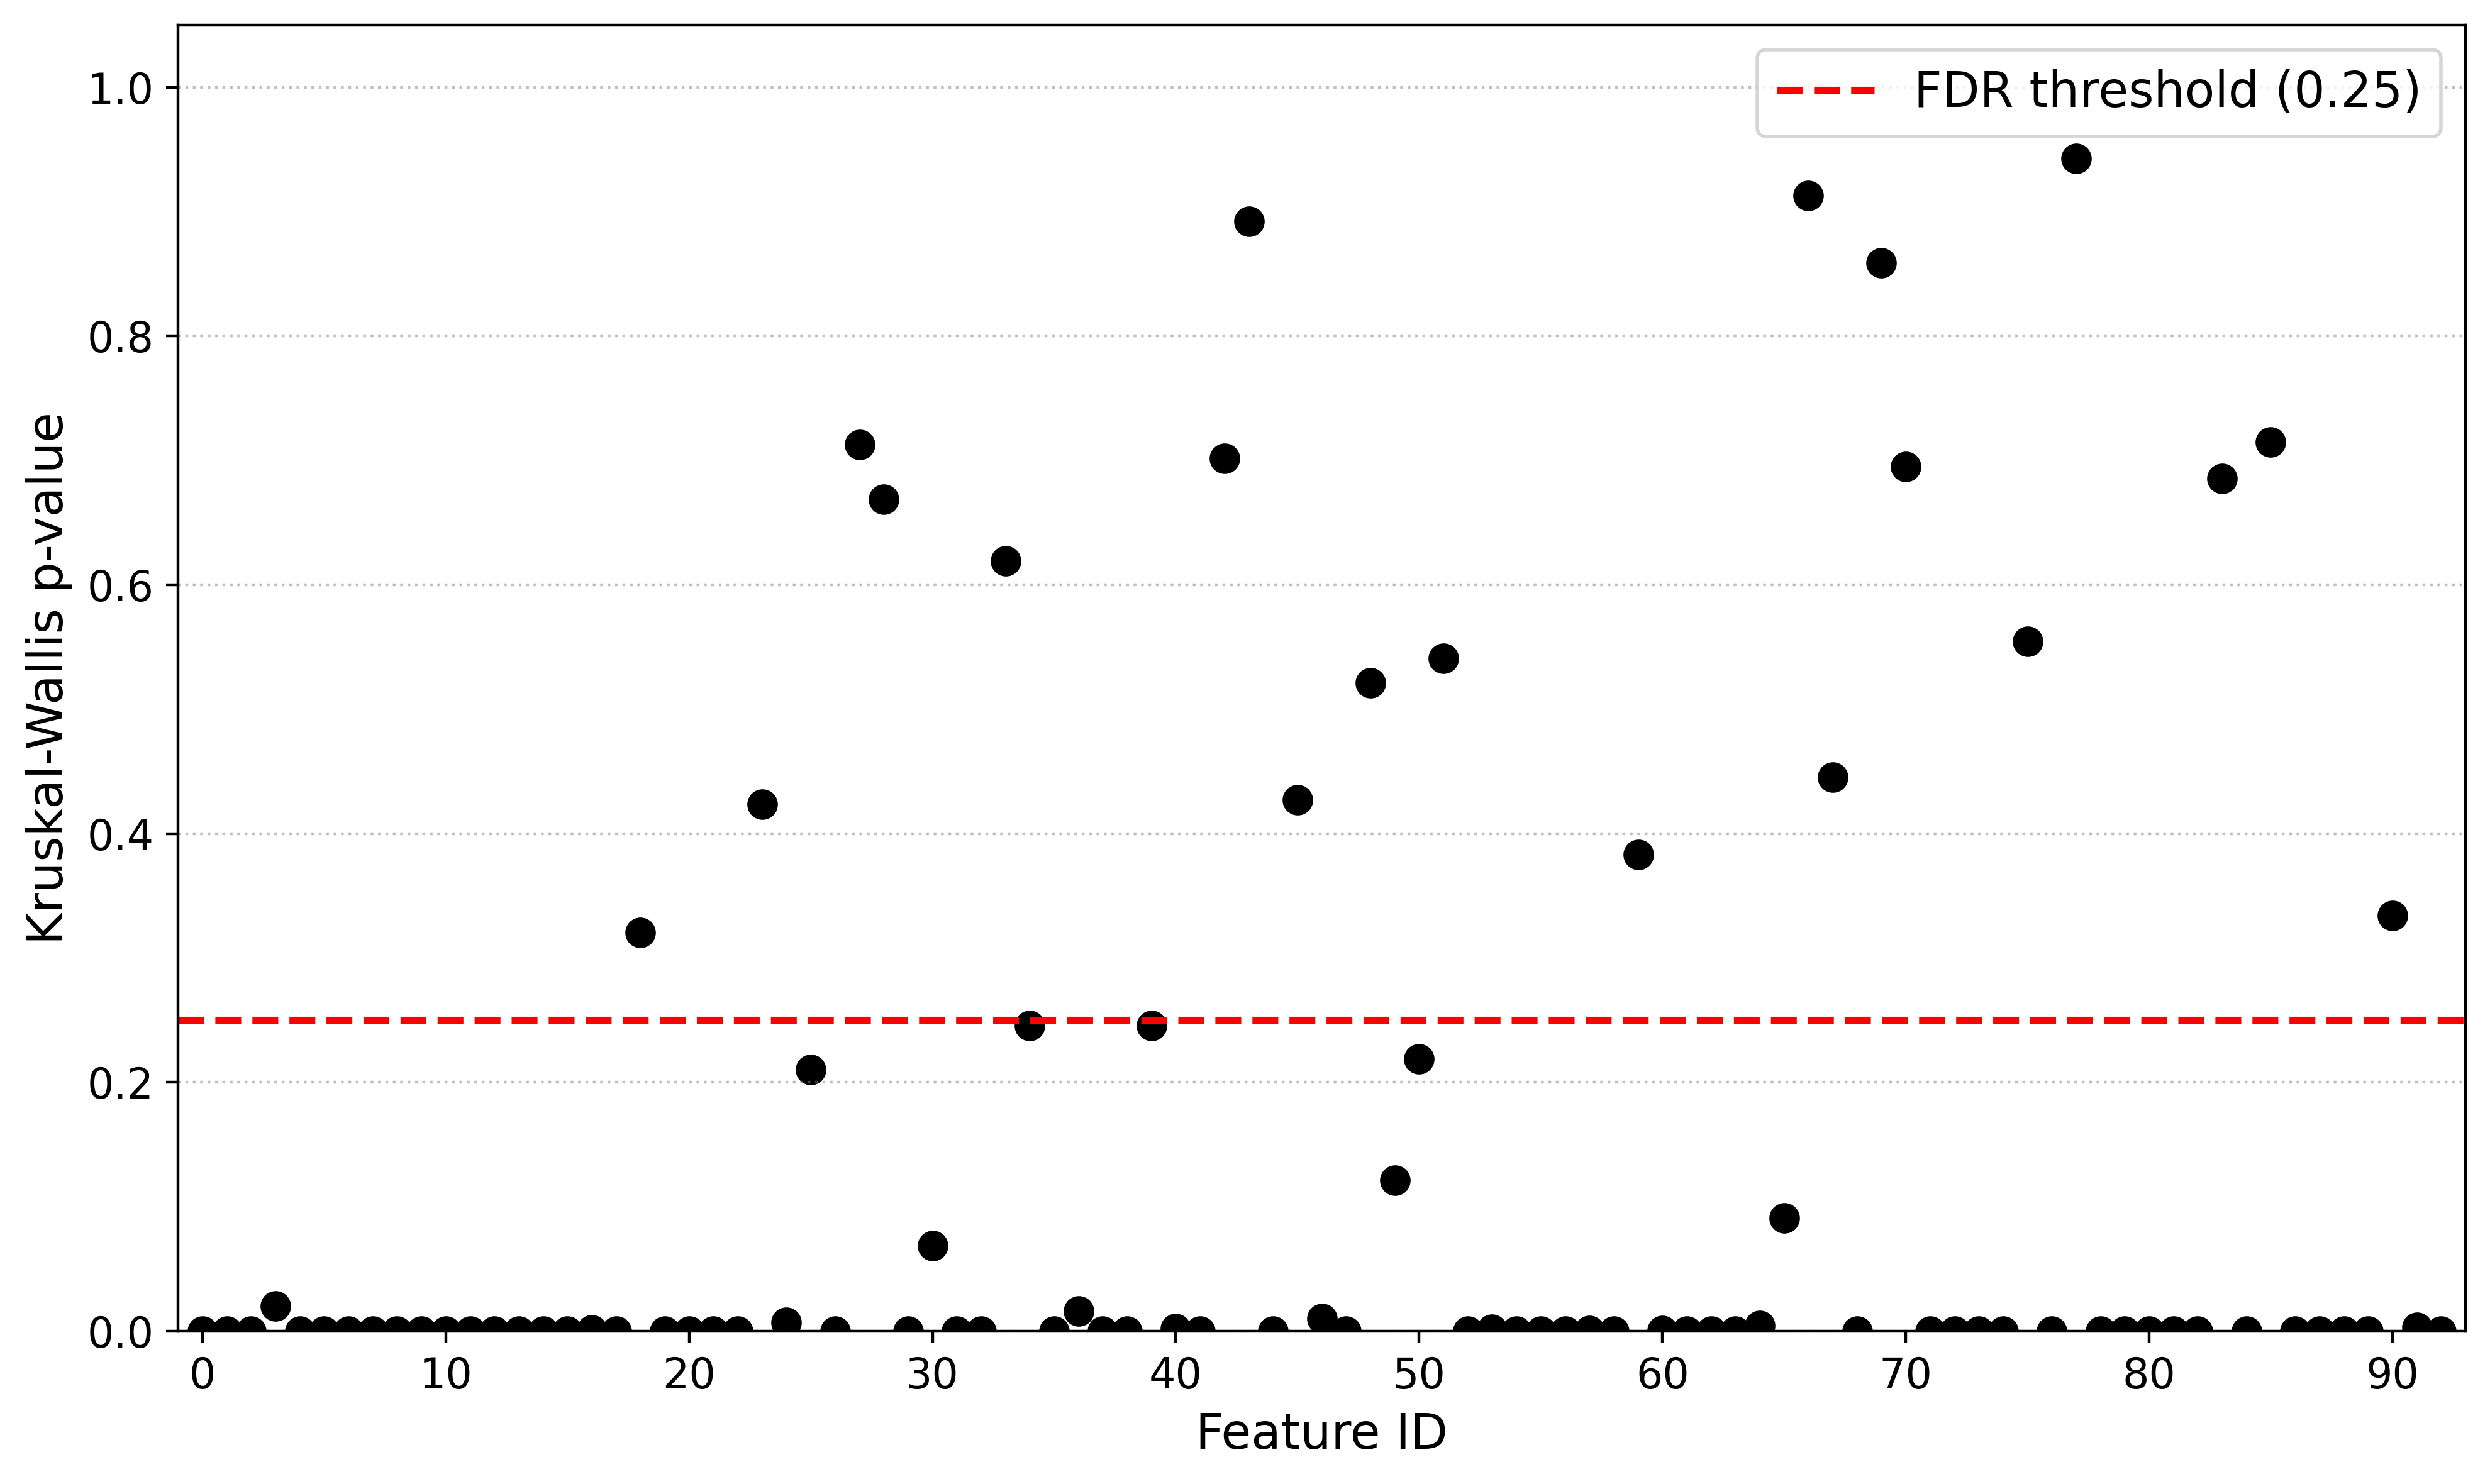

In [8]:
plot_kw_pvalues(kw_df)